In [1]:
!pip install numpy pandas scikit-fuzzy networkx matplotlib requests

In [2]:
import numpy as np
import pandas as pd
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
# Load the cleaned dataset
data = pd.read_csv('./remote_work_productivity.csv')

# Display first 30% of the dataset
percentage = 0.3
data[:int(len(data) * percentage)]

,Employee_ID,Age,Years_Experience,WFH_Days_Per_Week,Gender,Education_Level,Marital_Status,Has_Children,Location_Type,Department,...,Quality_Score,Innovation_Score,Efficiency_Rating,Meetings_Per_Week,Commute_Time_Minutes,Job_Satisfaction,Stress_Level,Work_Life_Balance,Survey_Date,Response_Quality
0,EMP0001,39,10,2,Female,Associate Degree,Married,Yes,Urban,Product,...,58.1,52.1,72.1,4,48,55.9,6,8,2024-04-05,Medium
1,EMP0002,33,4,5,Female,Master Degree,Married,No,Urban,Customer Success,...,93.3,77.9,89.5,12,0,96.1,3,8,2024-01-29,High
2,EMP0003,40,3,3,Male,PhD,Single,Yes,Rural,Operations,...,84.7,63.2,95.0,15,24,90.4,5,6,2024-01-18,High
3,EMP0004,48,14,3,Male,Bachelor Degree,Married,Yes,Urban,Finance,...,67.8,82.5,95.0,8,8,100.0,10,5,2024-04-18,High
4,EMP0005,32,6,5,Male,High School,Divorced,Yes,Rural,Engineering,...,86.4,67.5,95.0,10,0,100.0,3,4,2024-02-19,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,EMP0446,41,10,3,Female,Bachelor Degree,Married,Yes,Suburban,Engineering,...,86.7,71.0,92.7,9,35,100.0,10,7,2024-02-14,High
446,EMP0447,38,14,2,Male,Bachelor Degree,Married,No,Urban,Operations,...,94.6,84.7,95.0,12,25,81.7,3,9,2024-03-06,High
447,EMP0448,26,0,1,Male,Master Degree,Divorced,No,Urban,Engineering,...,69.7,71.2,85.6,9,33,100.0,7,2,2024-01-30,High
448,EMP0449,30,4,3,Male,Master Degree,Single,No,Urban,Marketing,...,60.8,56.4,67.7,7,32,98.1,8,5,2024-05-14,Medium


In [5]:
# Ambil nilai minimum dan maksimum dari kolom yang relevan
min_age = data['Age'].min()
max_age = data['Age'].max()

max_experience = data['Years_Experience'].max()
max_wfh = data['WFH_Days_Per_Week'].max()
max_quality = data['Quality_Score'].max()

print(f"Age Range: {min_age} - {max_age}")
print(f"Years of Experience Range: 0 - {max_experience}")
print(f"WFH Days Per Week Range: 0 - {max_wfh}")
print(f"Quality Score Range: 0 - {max_quality}")

# Define the universal variables
age = ctrl.Antecedent(np.arange(min_age, max_age + 1, 1), 'age')
experience = ctrl.Antecedent(np.arange(0, max_experience + 1, 1), 'experience')
wfh_days = ctrl.Antecedent(np.arange(0, max_wfh + 1, 1), 'wfh_days')
quality = ctrl.Consequent(np.arange(0, max_quality + 1, 1), 'quality')


Age Range: 22 - 65
Years of Experience Range: 0 - 32
WFH Days Per Week Range: 0 - 5
Quality Score Range: 0 - 100.0


In [6]:
%matplotlib inline
import skfuzzy as fuzz

# Age Membership Functions
age['young'] = fuzz.trapmf(age.universe, [min_age, min_age, 25, 35])
age['middle'] = fuzz.trimf(age.universe, [30, 40, 50])
age['old'] = fuzz.trapmf(age.universe, [45, 55, max_age, max_age])


# Years of Experience Membership Functions
experience['low'] = fuzz.trapmf(experience.universe, [0, 0, 3, 6])
experience['medium'] = fuzz.trimf(experience.universe, [4, 10, 16])
experience['high'] = fuzz.trapmf(experience.universe, [12, 20, max_experience, max_experience])

# WFH Days Per Week Membership Functions
wfh_days['rare'] = fuzz.trapmf(wfh_days.universe, [0, 0, 1, 2])
wfh_days['moderate'] = fuzz.trimf(wfh_days.universe, [1, 3, 4])
wfh_days['frequent'] = fuzz.trapmf(wfh_days.universe, [3, 4, max_wfh, max_wfh])

# Quality Score Membership Functions
quality['low'] = fuzz.trapmf(quality.universe, [0, 0, 40, 60])
quality['medium'] = fuzz.trimf(quality.universe, [50, 70, 85])
quality['high'] = fuzz.trapmf(quality.universe, [75, 90, max_quality, max_quality])


C:\Users\tiara\anaconda3\envs\env\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


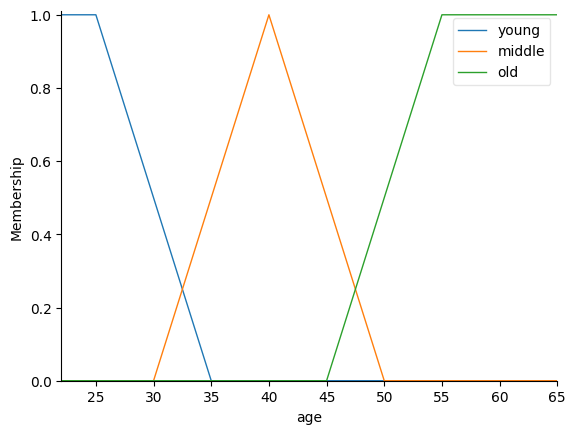

In [8]:
age.view()
plt.show()

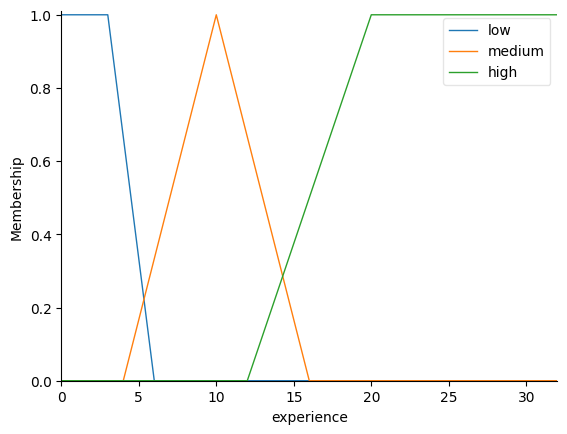

In [9]:
experience.view()
plt.show()

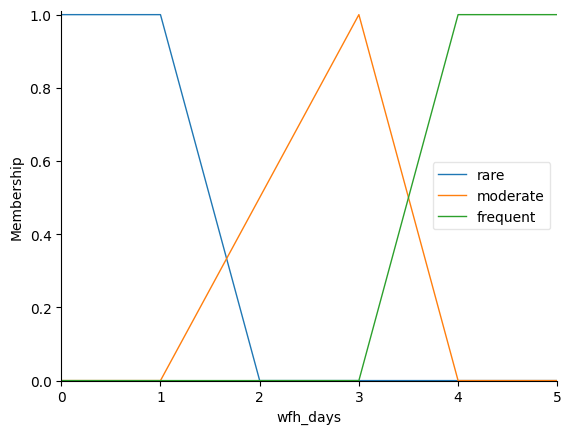

In [10]:
wfh_days.view()
plt.show()

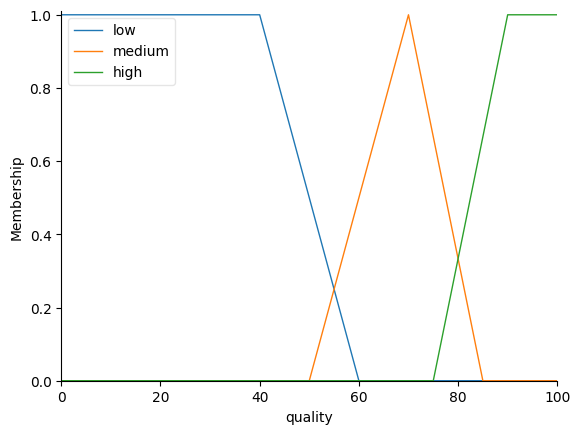

In [11]:
quality.view()
plt.show()

In [15]:
# Rule definitions (versi dataset kamu)
rule1 = ctrl.Rule(experience['high'] & wfh_days['frequent'], quality['high'])
rule2 = ctrl.Rule(experience['medium'] & wfh_days['moderate'], quality['medium'])
rule3 = ctrl.Rule(experience['low'] & wfh_days['rare'], quality['low'])
rule4 = ctrl.Rule(age['young'] & experience['high'], quality['high'])
rule5 = ctrl.Rule(age['middle'] & experience['medium'], quality['medium'])
rule6 = ctrl.Rule(age['old'] & wfh_days['rare'], quality['low'])
rule7 = ctrl.Rule(experience['high'] & wfh_days['moderate'], quality['high'])
rule8 = ctrl.Rule(experience['medium'] & wfh_days['frequent'], quality['medium'])
rule9 = ctrl.Rule(experience['low'] | wfh_days['rare'], quality['low'])
rule10 = ctrl.Rule(age['old'] & experience['low'], quality['low'])

In [16]:
# Build the control system with all rules
productivity_ctrl = ctrl.ControlSystem([
    rule1, rule2, rule3, rule4, rule5,
    rule6, rule7, rule8, rule9, rule10
])

In [18]:
# Function to compute productivity quality
def compute_productivity_quality(row):
    productivity_simulation = ctrl.ControlSystemSimulation(productivity_ctrl)

    # Ambil nilai dari kolom sesuai dataset kamu
    age_value = row['Age']
    experience_value = row['Years_Experience']
    wfh_days_value = row['WFH_Days_Per_Week']

    try:
        # Clip biar nilai tetap dalam range semesta fuzzy
        age_value = np.clip(age_value, age.universe[0], age.universe[-1])
        experience_value = np.clip(experience_value, experience.universe[0], experience.universe[-1])
        wfh_days_value = np.clip(wfh_days_value, wfh_days.universe[0], wfh_days.universe[-1])

        # Set input ke sistem fuzzy
        productivity_simulation.input['age'] = age_value
        productivity_simulation.input['experience'] = experience_value
        productivity_simulation.input['wfh_days'] = wfh_days_value

        # Jalankan perhitungan fuzzy
        productivity_simulation.compute()

        return productivity_simulation.output['quality']

    except Exception as ex:
        print(f"Error computing for row {row.name}: {ex}")
        print(f"Inputs: age={age_value}, experience={experience_value}, wfh_days={wfh_days_value}")
        return np.nan

# Apply ke seluruh dataset
data['predicted_quality'] = data.apply(compute_productivity_quality, axis=1)


In [19]:
data.head

<bound method NDFrame.head of      Employee_ID  Age  Years_Experience  WFH_Days_Per_Week      Gender  \
0        EMP0001   39                10                  2      Female   
1        EMP0002   33                 4                  5      Female   
2        EMP0003   40                 3                  3        Male   
3        EMP0004   48                14                  3        Male   
4        EMP0005   32                 6                  5        Male   
...          ...  ...               ...                ...         ...   
1495     EMP1496   53                 5                  5        Male   
1496     EMP1497   53                 9                  3  Non-binary   
1497     EMP1498   45                 2                  4        Male   
1498     EMP1499   44                12                  4      Female   
1499     EMP1500   40                 4                  5        Male   

       Education_Level Marital_Status Has_Children Location_Type  \
0     Associa

In [23]:
# Define a function to classify employee productivity quality
def classify_productivity(score):
    if score >= 70:
        return 'High'
    elif score >= 50:
        return 'Medium'
    else:
        return 'Low'

# Apply the classification
data['actual_quality_category'] = data['Quality_Score'].apply(classify_productivity)
data['predicted_quality_category'] = data['predicted_quality'].apply(classify_productivity)

In [24]:
# Display final comparison (tampilkan hanya 10 baris)
data[['Age', 'Years_Experience', 'WFH_Days_Per_Week',
      'Quality_Score', 'predicted_quality',
      'actual_quality_category', 'predicted_quality_category']].head(10)

,Age,Years_Experience,WFH_Days_Per_Week,Quality_Score,predicted_quality,actual_quality_category,predicted_quality_category
0,39,10,2,58.1,68.318182,Medium,Medium
1,33,4,5,93.3,26.805556,High,Low
2,40,3,3,84.7,25.333333,High,Low
3,48,14,3,67.8,75.045232,Medium,High
4,32,6,5,86.4,67.888889,High,Medium
5,32,7,4,60.6,68.055556,Medium,Medium
6,49,1,2,65.8,25.333333,Medium,Low
7,41,11,0,86.3,35.883785,High,Low
8,30,4,4,89.1,26.805556,High,Low
9,39,9,4,83.6,68.293651,High,Medium


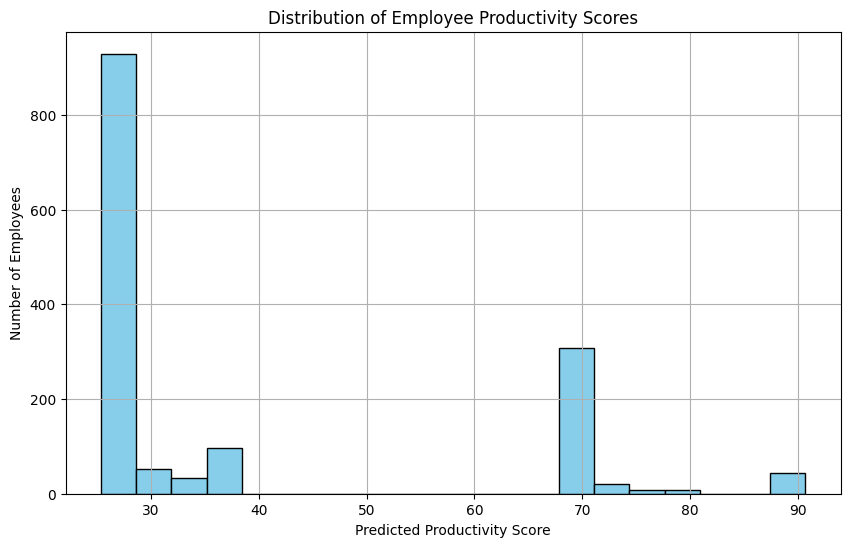

In [25]:
# Plot the distribution of employee productivity scores
plt.figure(figsize=(10,6))
plt.hist(data['predicted_quality'].dropna(), bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Employee Productivity Scores')
plt.xlabel('Predicted Productivity Score')
plt.ylabel('Number of Employees')
plt.grid(True)
plt.show()

Employee Productivity Category Counts:
predicted_quality_category
Low       1113
Medium     308
High        79
Name: count, dtype: int64


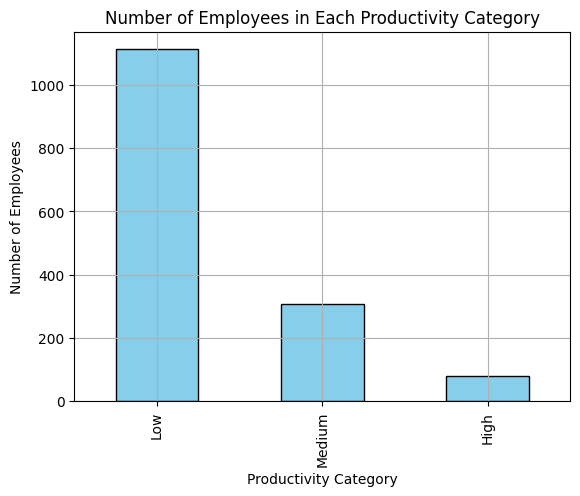

In [26]:
# Count the number of employees in each productivity category
category_counts = data['predicted_quality_category'].value_counts()
print("Employee Productivity Category Counts:")
print(category_counts)

# Plot the counts
category_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Number of Employees in Each Productivity Category')
plt.xlabel('Productivity Category')
plt.ylabel('Number of Employees')
plt.grid(True)
plt.show()